# GPT Model

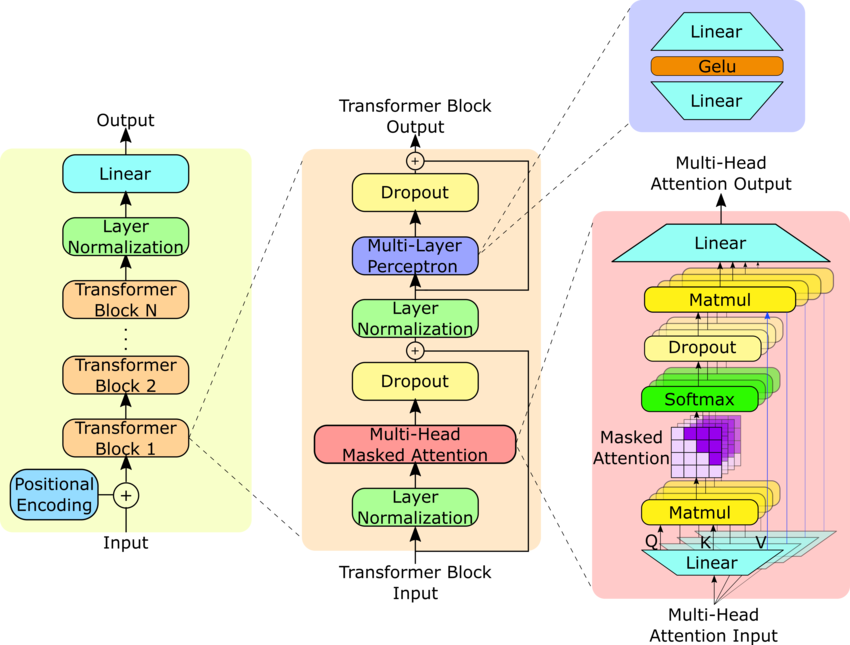

## What the code implements

A 124M-parameter GPT-2 style language model, built from two classes:

| Class | Role |
|---|---|
| `GPTModel` | The full model: embeddings → blocks → head |
| `TransformerBlock` | One repeating unit: attention + FFN, both with residual connections |

---

## Data flow (shape at each stage)

```
(2, 5) int IDs
   ↓  tok_emb + pos_emb
(2, 5, 768)  float vectors
   ↓  × 12 TransformerBlocks
(2, 5, 768)  enriched representations
   ↓  final LayerNorm
(2, 5, 768)
   ↓  out_head Linear
(2, 5, 50257)  logits
```

---

## Inside one TransformerBlock

```
x ──┬──► LayerNorm ──► MaskedSelfAttention ──► Dropout ──► (+) ──► x'
    │                                                         ▲
    └─────────────────────── shortcut ───────────────────────┘

x'──┬──► LayerNorm ──► FFN (768→3072→768) ──► Dropout ──► (+) ──► x''
    │                                                        ▲
    └────────────────────── shortcut ───────────────────────┘
```

Key design choices:

- **Pre-LN**: layer norm runs *before* each sub-layer (not after), which trains more stably.
- **Causal mask**: upper-triangular `-inf` mask ensures position `i` only attends to positions `≤ i`. Future tokens are invisible.
- **Residual connections**: the unchanged input is added back after each sub-layer, giving gradients a direct highway to earlier layers.
- **FFN width**: the hidden dim expands 4× (768 → 3072) inside the FFN. This is where the model stores factual associations.

---

## Config at a glance — GPT-2 Small

| Key | Value | What it controls |
|---|---|---|
| `vocab_size` | 50 257 | BPE vocabulary (GPT-2 tokeniser) |
| `context_length` | 1 024 | max tokens per forward pass |
| `emb_dim` | 768 | hidden vector size throughout |
| `n_heads` | 12 | attention heads (64-d each) |
| `n_layers` | 12 | stacked transformer blocks |
| `drop_rate` | 0.1 | dropout probability during training |

---

## Parameter count (approx.)

| Component | Params |
|---|---|
| Token embedding | 50 257 × 768 ≈ 38.6 M |
| Positional embedding | 1 024 × 768 ≈ 0.8 M |
| 12 × TransformerBlock | 12 × ~7 M ≈ 84 M |
| Output head | shares/mirrors token emb |
| **Total** | **~124 M** |

In [ ]:
import torch
import torch.nn as nn
import tiktoken

# ─────────────────────────────────────────────
# TRANSFORMER BLOCK
# The core repeating unit of GPT.
# Each block = one round of: attend → mix → refine.
# ─────────────────────────────────────────────
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # ── Multi-Head Self-Attention ──
        # Lets each token "look at" every token before it and
        # decide what information to pull in. The model learns
        # WHAT to pay attention to during training.
        # Note: in the book's full code this is a custom MHA class
        # from Ch3; here we use PyTorch's built-in equivalent.
        self.att = nn.MultiheadAttention(
            embed_dim=cfg["emb_dim"],   # size of each token vector (768 for GPT-2)
            num_heads=cfg["n_heads"],   # number of parallel attention "perspectives" (12)
            dropout=cfg["drop_rate"],   # randomly zero out some attention weights during training
            batch_first=True            # expect input as (batch, seq, features) not (seq, batch, features)
        )

        # ── Feed-Forward Network (FFN) ──
        # Applied independently to each token position after attention.
        # This is where the model stores factual knowledge.
        # The 4× expansion (768 → 3072 → 768) gives the model
        # a wide "scratch pad" to transform each token's meaning.
        self.ff = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),  # expand: 768 → 3072
            nn.GELU(),                                        # smooth non-linearity (preferred over ReLU in GPT)
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),  # compress back: 3072 → 768
        )

        # ── Layer Normalisation ──
        # Normalises activations before each sub-layer.
        # This is "Pre-LN" (norm BEFORE attention/FFN), which
        # trains more stably than the original "Post-LN" design.
        self.norm1 = nn.LayerNorm(cfg["emb_dim"])  # applied before attention
        self.norm2 = nn.LayerNorm(cfg["emb_dim"])  # applied before FFN

        # ── Dropout on residual path ──
        # Regularises the model by randomly dropping values
        # after each sub-layer before adding the shortcut.
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # ════ Sub-layer 1: Masked Self-Attention ════

        shortcut = x          # save input so we can add it back (residual connection)
        x = self.norm1(x)     # normalise BEFORE attention (Pre-LN)

        # Build a causal (autoregressive) mask so position i can only
        # attend to positions ≤ i. The upper triangle is -inf, which
        # becomes ~0 after softmax → those future positions are ignored.
        seq_len = x.shape[1]
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len) * float('-inf'),
            diagonal=1          # start filling -inf one step above the main diagonal
        ).to(x.device)

        # Self-attention: Q = K = V = x  (all three views come from the same input)
        x, _ = self.att(x, x, x, attn_mask=causal_mask, is_causal=True)

        x = self.drop_shortcut(x)   # dropout for regularisation
        x = x + shortcut            # ← residual / skip connection (stabilises gradient flow)

        # ════ Sub-layer 2: Position-wise Feed-Forward ════

        shortcut = x          # save post-attention state
        x = self.norm2(x)     # normalise BEFORE FFN (Pre-LN)
        x = self.ff(x)        # expand → GELU → compress
        x = self.drop_shortcut(x)
        x = x + shortcut      # ← second residual connection

        return x              # shape unchanged: (batch, seq_len, emb_dim)


# ─────────────────────────────────────────────
# GPT MODEL
# Stacks an embedding layer, N transformer blocks,
# and a final projection head to produce token logits.
# ─────────────────────────────────────────────
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        # ── Token Embedding ──
        # Maps each integer token ID → a learned 768-d vector.
        # Think of it as a look-up table that the model edits during training.
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])

        # ── Positional Embedding ──
        # Transformers have no inherent sense of order (attention is a set operation).
        # This adds a learned vector for each position (0, 1, …, 1023)
        # so the model knows WHERE each token sits in the sequence.
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # ── Embedding Dropout ──
        # Applied once after the combined embedding, before the transformer blocks.
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # ── Transformer Blocks ──
        # Stack cfg["n_layers"] (= 12) identical TransformerBlocks.
        # nn.Sequential chains them so x flows through block 0 → 1 → … → 11.
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        # ── Final Layer Norm ──
        # Normalises the output of the last transformer block
        # before projecting to vocabulary logits.
        self.final_norm = nn.LayerNorm(cfg["emb_dim"])

        # ── Language-Modelling Head ──
        # Linear projection: 768 → 50,257 (one score per vocab token).
        # No bias (matches GPT-2 design).
        # These logits are fed into softmax to get next-token probabilities.
        # Weight tying (tok_emb.weight == out_head.weight) is common but
        # not enforced here — note that both have shape (vocab_size, emb_dim).
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        # in_idx: (batch_size, seq_len)  — integer token IDs
        batch_size, seq_len = in_idx.shape

        # ── Step 1: Build embeddings ──
        tok_embeds = self.tok_emb(in_idx)                                   # (B, T, 768)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))  # (T, 768)

        # Broadcasting adds position info to every item in the batch.
        x = tok_embeds + pos_embeds    # (B, T, 768)
        x = self.drop_emb(x)

        # ── Step 2: Deep transformer processing ──
        # Each block refines the representation, building up richer context.
        x = self.trf_blocks(x)        # (B, T, 768) — shape unchanged through all 12 blocks

        # ── Step 3: Final normalisation ──
        x = self.final_norm(x)        # (B, T, 768)

        # ── Step 4: Project to vocabulary ──
        # Each of the T positions independently predicts the next token.
        logits = self.out_head(x)     # (B, T, 50257)
        return logits


# ─────────────────────────────────────────────
# CONFIGURATION — GPT-2 Small (124M parameters)
# ─────────────────────────────────────────────
GPT_CONFIG_124M = {
    "vocab_size":      50257,  # BPE vocabulary size (same as GPT-2)
    "context_length":   1024,  # max tokens the model can see at once
    "emb_dim":           768,  # hidden dimension throughout the model
    "n_heads":            12,  # attention heads per block (768 / 12 = 64-d per head)
    "n_layers":           12,  # number of stacked transformer blocks
    "drop_rate":         0.1,  # 10% dropout during training
    "qkv_bias":        False,  # GPT-2 uses no bias in Q/K/V projections
}

# ─────────────────────────────────────────────
# SMOKE TEST
# ─────────────────────────────────────────────
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

# Two sentences, each 5 tokens long (just random IDs here)
mock_input_ids = torch.tensor([[124, 55, 66, 77, 88],
                                [99, 100, 101, 102, 103]])

logits = model(mock_input_ids)

print("Input shape  (Batch, Seq_Len):              ", mock_input_ids.shape)   # (2, 5)
print("Logits shape (Batch, Seq_Len, Vocab_Size):  ", logits.shape)           # (2, 5, 50257)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")  # ~124 M

Input shape  (Batch, Seq_Len):               torch.Size([2, 5])
Logits shape (Batch, Seq_Len, Vocab_Size):   torch.Size([2, 5, 50257])
Total parameters: 163.04 M


# KV Cache

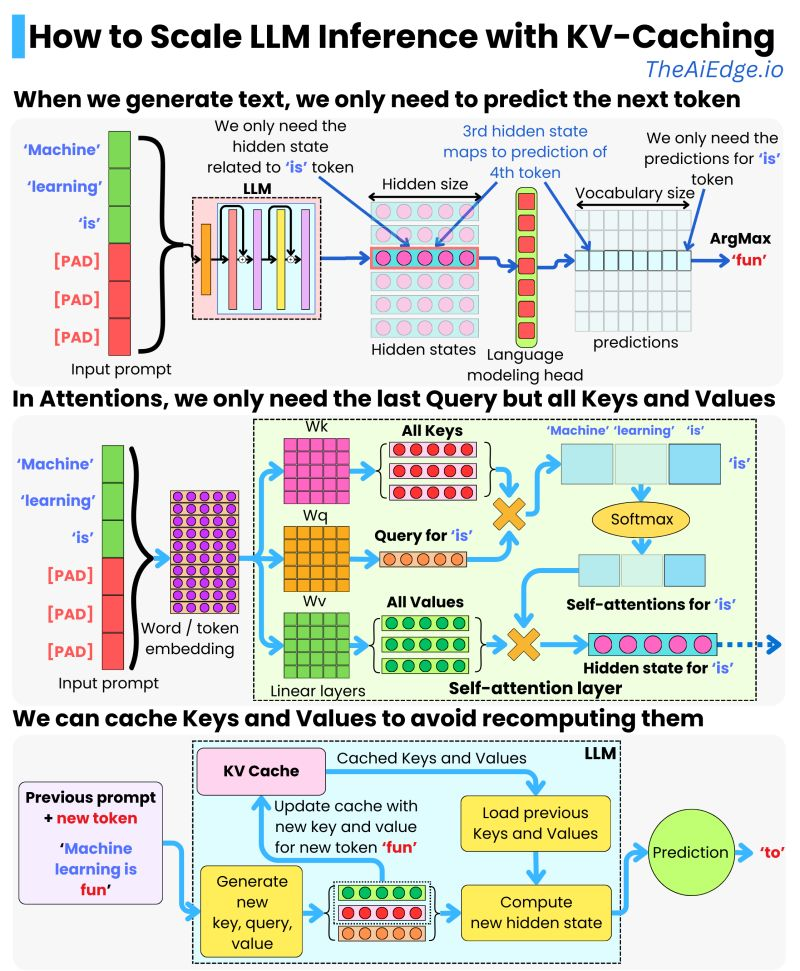

## The Core Idea

Without a cache, generating each new token means re-running the **entire sequence** through every transformer layer — O(n) work per token that compounds badly. The KV cache fixes this by saving each layer's computed **Keys** and **Values** from past tokens. On subsequent steps you only process **one new token**, then concatenate its K/V onto the saved history.

---

## The Three Classes

### `MultiHeadAttentionKVCache`
Standard multi-head attention with one addition: an optional `kv_cache` argument.

- Projects input `x` into Q, K, V and reshapes into `[batch, heads, seq_len, head_dim]`
- If a cache exists, **concatenates** past keys/values to the left of the new ones along the sequence dimension
- Returns the updated `(keys, values)` tuple so the next step can extend it
- Causal mask is **skipped** when `num_tokens == 1` — the single query token is already last, so masking is unnecessary

### `TransformerBlockKVCache`
A standard transformer block (pre-norm → attention → residual → pre-norm → FFN → residual). The KV cache just threads straight through the attention layer and is passed back up unchanged.

### `GPTModelKVCache`
Stacks N transformer blocks between an embedding layer and an output head.

- **Prefill** (`past_kv_caches=None`): positions are `0, 1, 2, … seq_len-1`
- **Generation** (cache exists): position = `past_cache_length`, so the new token gets the correct absolute position
- Each block returns its updated cache; the model collects them into a list and returns it

---

## The Generation Loop (`generate_with_kv_cache`)

Two distinct phases per call:

| Step | Input to model | What happens |
|------|---------------|--------------|
| 1 — prefill | Full prompt `idx` | KV cache is built for all layers |
| 2…N — generation | Only `idx[:, -1:]` (last token) | Cache extended by 1; next token predicted |

After each forward pass:
1. Take logits at the **last position only** (`logits[:, -1, :]`)
2. `argmax` → next token id (greedy decoding)
3. Append to `idx` and loop

---

## Key Shapes to Keep in Mind

```
Q: [batch, heads, 1,        head_dim]   ← just the new token during generation
K: [batch, heads, total_len, head_dim]  ← past cache + new token
V: [batch, heads, total_len, head_dim]  ← same
attn_scores: [batch, heads, 1, total_len]
```

`total_len` grows by 1 each generation step — that's the whole point.

---

## Why It Works

- **O(n) → O(1) per step**: instead of re-computing K/V for every token on every step, you compute them once and read them from the cache
- **Correctness**: positional embeddings use absolute indices (`past_length + new_token_position`), so the model still knows where each token sits in the sequence
- **No mask needed during generation**: a single query attending to everything to its left is already causal by definition

In [ ]:
import torch
import torch.nn as nn
import tiktoken


# =============================================================================
# WHAT IS A KV CACHE?
# Without a cache, every new token forces you to reprocess the entire sequence
# through all transformer layers — extremely wasteful. With a cache, each
# attention layer saves its computed Keys (K) and Values (V) from past tokens.
# On the next step you only process ONE new token, then concatenate the new K/V
# onto the saved history. Cost drops from O(n²) to O(n) per step.
# =============================================================================


# -----------------------------------------------------------------------------
# LAYER 1: MULTI-HEAD ATTENTION (with KV cache support)
# -----------------------------------------------------------------------------
class MultiHeadAttentionKVCache(nn.Module):
    """
    Standard multi-head self-attention, augmented with an optional KV cache.

    Shape conventions used throughout this class:
      b           = batch size
      num_tokens  = sequence length of the CURRENT input (1 during generation)
      d_in / d_out = input / output embedding dimension
      num_heads   = number of parallel attention heads
      head_dim    = d_out // num_heads  (features per head)
      total_len   = num_tokens + length of cached history
    """

    def __init__(self, d_in, d_out, context_length, num_heads):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must divide evenly across heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Features each head processes

        # Three independent linear projections — no bias (common in GPT-style models)
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)

        # Merges the outputs of all heads back into one vector
        self.out_proj = nn.Linear(d_out, d_out, bias=False)

        # Causal (upper-triangular) mask: token i may NOT attend to token j > i.
        # Stored as a non-trainable buffer so it moves to GPU with the model.
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x, use_cache=False, kv_cache=None):
        """
        Args:
            x          : [b, num_tokens, d_in]  — current input tokens
            use_cache  : whether to read/write the KV cache at all
            kv_cache   : (past_keys, past_values) | None
                           past_keys   : [b, num_heads, past_len, head_dim]
                           past_values : [b, num_heads, past_len, head_dim]

        Returns:
            output   : [b, num_tokens, d_out]
            kv_cache : updated (keys, values) tuple (or None if use_cache=False)
        """
        b, num_tokens, d_in = x.shape

        # --- Project input into Q, K, V and split into heads ---
        # Linear → reshape to [b, num_tokens, num_heads, head_dim] → transpose
        # so heads sit on dim-1: [b, num_heads, num_tokens, head_dim]
        queries = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        keys    = self.W_key(x)  .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # --- Append cached history (generation phase only) ---
        if use_cache:
            if kv_cache is not None:
                past_keys, past_values = kv_cache
                # Glue old keys/values to the left of the new ones along the
                # sequence dimension (dim=2).  Shape becomes:
                #   [b, num_heads, past_len + num_tokens, head_dim]
                keys   = torch.cat((past_keys,   keys),   dim=2)
                values = torch.cat((past_values, values), dim=2)

            # Package the *full* history (old + new) for the next iteration
            kv_cache = (keys, values)

        # --- Scaled dot-product attention ---
        # queries: [b, heads, num_tokens, head_dim]
        # keys.T:  [b, heads, head_dim,   total_len]
        # scores:  [b, heads, num_tokens, total_len]
        attn_scores = queries @ keys.transpose(2, 3)

        # Apply the causal mask ONLY during prefill (processing > 1 token).
        # During generation num_tokens == 1, so the single query is already the
        # last token — it can legally attend to everything in the cache.
        if not use_cache or num_tokens > 1:
            mask_bool = self.mask.bool()[:num_tokens, :keys.shape[2]]
            attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Scale by 1/√head_dim to prevent dot-products from exploding in magnitude
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)

        # Weighted sum of values, then merge heads back into a flat vector
        # [b, heads, num_tokens, head_dim] → [b, num_tokens, heads, head_dim]
        #   → reshape → [b, num_tokens, d_out]
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.reshape(b, num_tokens, self.d_out)

        return self.out_proj(context_vec), kv_cache


# -----------------------------------------------------------------------------
# LAYER 2: TRANSFORMER BLOCK  (attention + feed-forward + residual connections)
# -----------------------------------------------------------------------------
class TransformerBlockKVCache(nn.Module):
    """
    One standard transformer block:
      ┌─────────────────────────────────────────────────────┐
      │  x → LayerNorm → Multi-Head Attention → + residual  │
      │    → LayerNorm → Feed-Forward Network → + residual  │
      └─────────────────────────────────────────────────────┘
    The KV cache threads straight through the attention layer unchanged.
    """

    def __init__(self, cfg):
        super().__init__()

        # Attention sub-layer
        self.att = MultiHeadAttentionKVCache(
            cfg["emb_dim"], cfg["emb_dim"],
            cfg["context_length"], cfg["n_heads"]
        )

        # Feed-forward sub-layer: expand → GELU → contract
        # The 4× expansion is the standard "bottleneck" from the GPT-2 paper.
        self.ff = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
        )

        # Pre-norm LayerNorm (applied BEFORE each sub-layer, not after)
        self.norm1 = nn.LayerNorm(cfg["emb_dim"])
        self.norm2 = nn.LayerNorm(cfg["emb_dim"])

    def forward(self, x, use_cache=False, kv_cache=None):
        # --- Attention sub-layer with residual ---
        shortcut = x
        x, kv_cache = self.att(self.norm1(x), use_cache=use_cache, kv_cache=kv_cache)
        x = x + shortcut  # Residual: lets gradients flow directly to earlier layers

        # --- Feed-forward sub-layer with residual ---
        shortcut = x
        x = self.ff(self.norm2(x))
        x = x + shortcut

        return x, kv_cache


# -----------------------------------------------------------------------------
# FULL MODEL: stacked transformer blocks + embedding layers + output head
# -----------------------------------------------------------------------------
class GPTModelKVCache(nn.Module):
    """
    Minimal GPT-style language model.

    Token IDs  →  Embeddings  →  N Transformer Blocks  →  Logits over vocab

    Key design:
    - Token embedding  : maps integer token IDs → dense vectors
    - Position embedding: gives the model a sense of token order
      (learned, not sinusoidal — same as GPT-2)
    - Output head      : projects each position back to vocab size for next-token prediction
    """

    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])

        # Build the tower of transformer blocks
        self.trf_blocks = nn.ModuleList(
            [TransformerBlockKVCache(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = nn.LayerNorm(cfg["emb_dim"])

        # No bias on the output projection (standard for GPT-style models)
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx, use_cache=False, past_kv_caches=None):
        """
        Args:
            in_idx         : [batch, seq_len]  — token IDs to process
            use_cache      : enable KV caching
            past_kv_caches : list of per-layer (keys, values) tuples, or None
                             (None signals this is the very first call / prefill)

        Returns:
            logits          : [batch, seq_len, vocab_size]
            updated_kv_caches : list of updated per-layer (keys, values) tuples
        """
        batch_size, seq_len = in_idx.shape

        # --- Position indices ---
        # Prefill  (past_kv_caches is None): positions are 0, 1, 2, …, seq_len-1
        # Generation (cache exists):         position = length of the saved cache
        #   e.g. if 8 tokens are already cached, the new token gets position 8
        if past_kv_caches is None:
            pos_indices = torch.arange(seq_len, device=in_idx.device)
            past_kv_caches = [None] * len(self.trf_blocks)  # one slot per layer
        else:
            past_length = past_kv_caches[0][0].shape[2]  # sequence dimension of layer-0 cache
            pos_indices = torch.arange(past_length, past_length + seq_len, device=in_idx.device)

        # Combine token meaning and token position into one vector
        x = self.tok_emb(in_idx) + self.pos_emb(pos_indices)

        # Pass data through each transformer block, threading the cache forward
        updated_kv_caches = []
        for i, block in enumerate(self.trf_blocks):
            x, cache = block(x, use_cache=use_cache, kv_cache=past_kv_caches[i])
            updated_kv_caches.append(cache)

        logits = self.out_head(self.final_norm(x))

        return logits, updated_kv_caches


# =============================================================================
# AUTOREGRESSIVE GENERATION LOOP
# =============================================================================
def generate_with_kv_cache(model, initial_idx, max_new_tokens):
    """
    Generate `max_new_tokens` tokens one at a time, using the KV cache to avoid
    reprocessing the prompt on every step.

    Two-phase behaviour:
      Step 1 (prefill)  — send the full prompt through the model; this builds
                          and fills the KV cache for every layer.
      Steps 2-N (gen.)  — send only the single newest token; the model extends
                          its cache by one slot and predicts the next token.

    Args:
        model          : GPTModelKVCache instance
        initial_idx    : [1, prompt_len]  — encoded prompt token IDs
        max_new_tokens : how many tokens to generate

    Returns:
        idx : [1, prompt_len + max_new_tokens]  — full token sequence
    """
    model.eval()
    idx = initial_idx
    kv_caches = None  # None signals "no cache yet → run prefill on first call"

    for step in range(max_new_tokens):

        # ── ROUTING: what to send to the model ──────────────────────────────
        # First step: no cache exists yet, send the whole prompt.
        # Every later step: cache is warm, send ONLY the last (newest) token.
        if kv_caches is None:
            current_input = idx           # shape: [1, prompt_len]
        else:
            current_input = idx[:, -1:]   # shape: [1, 1] — just the last token

        # ── FORWARD PASS ─────────────────────────────────────────────────────
        with torch.no_grad():
            # kv_caches is updated in place (conceptually) — the new list is
            # returned and replaces the old one each iteration.
            logits, kv_caches = model(current_input, use_cache=True, past_kv_caches=kv_caches)

        # ── NEXT-TOKEN PREDICTION ────────────────────────────────────────────
        # We only care about the prediction at the *last* position in the output.
        # logits[:, -1, :] has shape [1, vocab_size]
        next_token_logits = logits[:, -1, :]
        idx_next = torch.argmax(next_token_logits, dim=-1, keepdim=True)  # greedy

        # ── APPEND & LOOP ────────────────────────────────────────────────────
        # Grow the running sequence so the next step can use idx[:, -1:] correctly
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# =============================================================================
# QUICK SMOKE TEST
# =============================================================================
if __name__ == "__main__":
    # Deliberately small config so this runs fast on CPU
    GPT_CONFIG = {
        "vocab_size":      50257,  # GPT-2 vocabulary
        "context_length":  1024,   # max sequence length
        "emb_dim":         256,    # embedding / hidden size (GPT-2 uses 768)
        "n_heads":         8,      # attention heads (emb_dim must divide evenly)
        "n_layers":        4,      # transformer blocks stacked (GPT-2 uses 12)
    }

    torch.manual_seed(123)
    model = GPTModelKVCache(GPT_CONFIG)
    tokenizer = tiktoken.get_encoding("gpt2")

    prompt = "The architecture of a neural network is"
    encoded_prompt = torch.tensor([tokenizer.encode(prompt)])  # [1, prompt_len]

    print(f"Prompt : '{prompt}'")
    print(f"Token IDs: {encoded_prompt.tolist()[0]}")
    print("\nGenerating with KV cache...")

    output_ids = generate_with_kv_cache(model, encoded_prompt, max_new_tokens=10)

    decoded_text = tokenizer.decode(output_ids[0].tolist())
    print(f"\nOutput : {decoded_text}")
    print("\nNote: weights are random so the output is gibberish — but the pipeline runs correctly.")

Prompt : 'The architecture of a neural network is'
Token IDs: [464, 10959, 286, 257, 17019, 3127, 318]

Generating with KV cache...

Output : The architecture of a neural network is that depictionanse 43igiousCome edible rg428 borrowed

Note: weights are random so the output is gibberish — but the pipeline runs correctly.


# Mixture of Experts

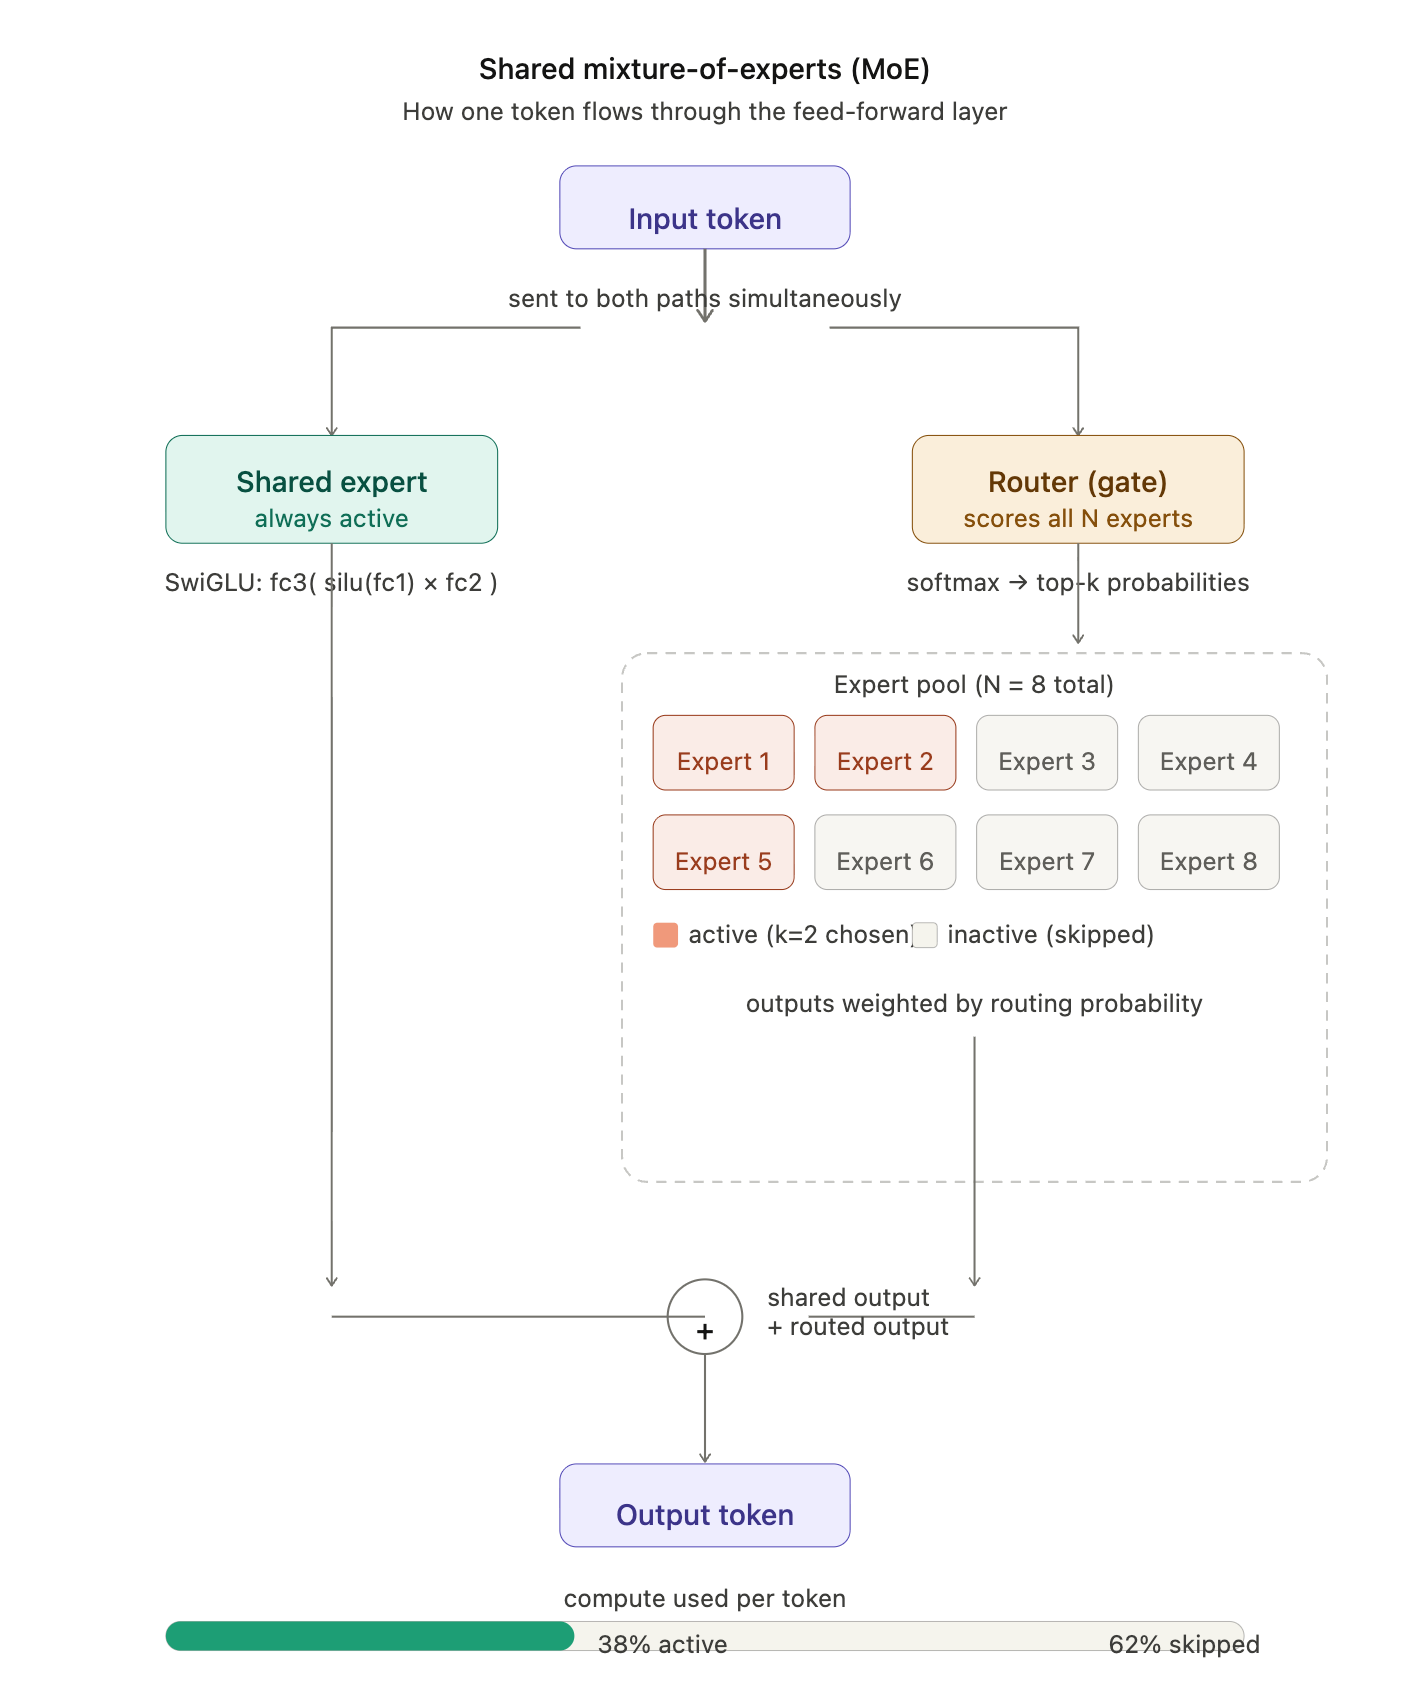

## Core Idea
A GPT-style transformer where the standard feed-forward MLP is replaced with a **Shared MoE layer**. The model stores many expert MLPs in memory but only activates a few per token, saving compute while keeping a large parameter count.

---

## Building Blocks

### `LayerNorm`
Custom layer normalisation. Normalises each token's embedding to zero mean / unit variance, then applies learnable scale (γ) and shift (β). Applied **before** each sub-layer (Pre-LN style).

### `MultiHeadAttention`
Standard causal self-attention. Tokens can only attend to **past and present** positions — future positions are masked to `–∞` before softmax so they get ~0 weight. Input is split into multiple heads, attention is computed independently per head, then merged back.

---

## The Key Layer — `SharedMoEFeedForward`
Replaces the plain MLP. Three parts run for every token:

**A. Shared Expert** — always runs, every token. Acts as a generalist knowledge base.

**B. Router (Gate)** — a linear layer that scores all `N` experts and picks the top `k` for this token. Scores are softmaxed into routing probabilities.

**C. Routed Experts** — only the `k` selected experts run. Each expert's output is weighted by its routing probability. Experts not selected this step are skipped entirely (free compute).

**Final output = Shared Expert output + weighted sum of Routed Expert outputs**

All experts use **SwiGLU** activation: `fc3( silu(fc1(x)) * fc2(x) )`

---

## Full Model — `GPTModelSharedMoE`
```
Token IDs → Token Embedding + Positional Embedding
          → N × TransformerBlock [ Attention → MoE FFN ]
          → LayerNorm → Linear → Logits (vocab size)
```
Each `TransformerBlock` is: **Pre-LN → sub-layer → residual add**, repeated for attention and the MoE FFN.

---

## Generation — `generate_text_simple`
Greedy autoregressive loop. At each step: crop to context window → forward pass → take the highest-logit token → append → repeat.

---

## Why MoE?
| | Dense MLP | Shared MoE |
|---|---|---|
| Parameters in memory | All active | Large (N experts stored) |
| Parameters per forward pass | All | Router + Shared + k experts |
| Benefit | Simple | More capacity, same compute cost |

In the demo config (`N=8` experts, `k=2`), only ~40% of the FFN parameters are used per token.

In [5]:
"""
gpt_shared_moe_commented.py
============================
A small GPT-style language model that uses a "Shared Mixture-of-Experts" (MoE)
feed-forward layer instead of a plain MLP.

Key idea
--------
Normal transformer: every token → same big MLP (expensive, uniform).
MoE transformer:    every token → 1 shared "generalist" expert
                                + 2 "specialist" experts chosen by a router.

This means the model has many parameters stored in memory, but only a small
subset are used (activated) for each token — making forward passes cheaper.

Dependencies: torch, tiktoken
"""

import torch
import torch.nn as nn
import tiktoken


# ══════════════════════════════════════════════════════════════
# SECTION 1 – UTILITY LAYERS
# ══════════════════════════════════════════════════════════════

class LayerNorm(nn.Module):
    """
    Layer Normalisation (custom implementation for clarity).

    Normalises each token's embedding vector to have ~zero mean and ~unit
    variance, then applies learnable per-dimension scale and shift.
    This stabilises training and is applied *before* each sub-layer
    (a.k.a. "Pre-LN" style).

    Args:
        emb_dim (int): Size of the embedding (i.e. the last tensor dimension).
    """

    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5                                      # small constant to prevent division by zero
        self.scale = nn.Parameter(torch.ones(emb_dim))      # learnable γ (gamma)
        self.shift = nn.Parameter(torch.zeros(emb_dim))     # learnable β (beta)

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var  = x.var(dim=-1,  keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)    # zero-mean, unit-var
        return self.scale * norm_x + self.shift              # re-scale and re-shift


class MultiHeadAttention(nn.Module):
    """
    Causal (masked) Multi-Head Self-Attention.

    Each token can attend to all *previous* tokens (and itself), but NOT to
    future tokens — this is enforced by the upper-triangular causal mask.

    Args:
        d_in  (int): Input embedding dimension.
        d_out (int): Output embedding dimension (must be divisible by num_heads).
        context_length (int): Maximum sequence length supported.
        num_heads (int): Number of attention heads to split computation into.
    """

    def __init__(self, d_in, d_out, context_length, num_heads):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.num_heads = num_heads
        self.head_dim  = d_out // num_heads          # dimension handled by each head

        # Linear projections that create Q, K, V matrices from the input
        self.W_query = nn.Linear(d_in, d_out, bias=False)
        self.W_key   = nn.Linear(d_in, d_out, bias=False)
        self.W_value = nn.Linear(d_in, d_out, bias=False)

        # Final projection that merges all head outputs back into d_out
        self.out_proj = nn.Linear(d_out, d_out, bias=False)

        # Causal mask: upper triangle is True → those positions get –∞ before softmax
        # register_buffer saves it as part of the model state (moves to GPU with model)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        # 1. Project input to Q, K, V and split into heads
        #    Shape after view+transpose: (batch, num_heads, seq_len, head_dim)
        keys    = self.W_key(x)  .view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        queries = self.W_query(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)
        values  = self.W_value(x).view(b, num_tokens, self.num_heads, self.head_dim).transpose(1, 2)

        # 2. Compute raw attention scores: Q · Kᵀ
        attn_scores = queries @ keys.transpose(2, 3)   # (b, heads, seq, seq)

        # 3. Apply causal mask — future positions become –∞ so softmax gives them ~0 weight
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # 4. Scale and normalise → attention weights (rows sum to 1)
        attn_weights = torch.softmax(attn_scores / (self.head_dim ** 0.5), dim=-1)

        # 5. Weighted sum of values, then merge heads back into a single vector
        context_vec = (
            (attn_weights @ values)          # (b, heads, seq, head_dim)
            .transpose(1, 2)                 # (b, seq, heads, head_dim)
            .contiguous()
            .view(b, num_tokens, d_in)       # (b, seq, d_out)
        )

        return self.out_proj(context_vec)    # final linear mix across heads


# ══════════════════════════════════════════════════════════════
# SECTION 2 – SHARED MIXTURE-OF-EXPERTS FEED-FORWARD LAYER
# ══════════════════════════════════════════════════════════════

class SharedMoEFeedForward(nn.Module):
    """
    Feed-forward block with a Shared Mixture-of-Experts design.

    Architecture (per token):
    ┌───────────────────────────────────────────────┐
    │  Input embedding x                            │
    │         │                    │                │
    │   Shared Expert          Routing Gate         │
    │  (always active)        (picks top-k)         │
    │         │                    │                │
    │         │           Top-k Routed Experts      │
    │         │          (weighted by router probs) │
    │         │                    │                │
    │         └────────(+)─────────┘                │
    │                  │                            │
    │            Output embedding                   │
    └───────────────────────────────────────────────┘

    Every expert uses a SwiGLU activation:
        output = fc3( silu(fc1(x)) * fc2(x) )
    This is the same activation used in LLaMA and Mistral.

    Args:
        cfg (dict): Model config dict — see CFG below for required keys.
    """

    def __init__(self, cfg):
        super().__init__()
        self.num_experts_per_tok = cfg["num_experts_per_tok"]   # k: how many routed experts activate per token
        self.num_experts         = cfg["num_experts"]           # total number of routed experts available
        self.emb_dim             = cfg["emb_dim"]

        # ── Router (Gate) ──────────────────────────────────────────────────
        # A single linear layer that scores each of the N experts for a token.
        # Output shape: (batch, seq_len, num_experts) → one score per expert.
        self.gate = nn.Linear(cfg["emb_dim"], cfg["num_experts"], bias=False)

        # ── Routed Experts (one set of 3 weight matrices per expert) ───────
        # fc1 and fc2 are the "gate" and "up" projections (SwiGLU style).
        # fc3 is the "down" projection that maps back to emb_dim.
        self.fc1 = nn.ModuleList([nn.Linear(cfg["emb_dim"],    cfg["hidden_dim"], bias=False) for _ in range(self.num_experts)])
        self.fc2 = nn.ModuleList([nn.Linear(cfg["emb_dim"],    cfg["hidden_dim"], bias=False) for _ in range(self.num_experts)])
        self.fc3 = nn.ModuleList([nn.Linear(cfg["hidden_dim"], cfg["emb_dim"],    bias=False) for _ in range(self.num_experts)])

        # ── Shared Expert (one set of weights, always runs) ────────────────
        # This expert acts as a "generalist backbone" — every token benefits
        # from it regardless of what the router decides.
        self.shared_fc1 = nn.Linear(cfg["emb_dim"],    cfg["hidden_dim"], bias=False)
        self.shared_fc2 = nn.Linear(cfg["emb_dim"],    cfg["hidden_dim"], bias=False)
        self.shared_fc3 = nn.Linear(cfg["hidden_dim"], cfg["emb_dim"],    bias=False)

    def forward(self, x):
        """
        x: (batch, seq_len, emb_dim)
        returns: (batch, seq_len, emb_dim)
        """
        batch, seq_len, _ = x.shape

        # ── PART A: Shared Expert (always active) ──────────────────────────
        # SwiGLU: element-wise gate (silu) multiplied by a second projection
        shared_hidden = torch.nn.functional.silu(self.shared_fc1(x)) * self.shared_fc2(x)
        shared_out    = self.shared_fc3(shared_hidden)   # shape: (batch, seq_len, emb_dim)

        # ── PART B: Routing — which k experts should each token use? ───────
        scores = self.gate(x)                                    # (batch, seq_len, num_experts)
        topk_scores, topk_indices = torch.topk(scores, self.num_experts_per_tok, dim=-1)
        # Convert raw scores to probabilities — used to weight expert outputs
        topk_probs = torch.softmax(topk_scores, dim=-1)         # (batch, seq_len, k)

        # Flatten batch and seq dimensions so we process tokens one-by-one
        # Shape: (batch*seq_len, emb_dim)
        x_flat = x.reshape(batch * seq_len, -1)

        # Buffer to accumulate weighted expert outputs for every token
        out_flat = torch.zeros(batch * seq_len, self.emb_dim, device=x.device, dtype=x.dtype)

        # Also flatten the routing assignments
        topk_indices_flat = topk_indices.reshape(-1, self.num_experts_per_tok)   # (N, k)
        topk_probs_flat   = topk_probs  .reshape(-1, self.num_experts_per_tok)   # (N, k)

        # ── PART B (cont.): Run each expert only on tokens routed to it ───
        # We loop over *unique* expert IDs that were actually selected this
        # forward pass — experts no token chose are skipped entirely (free!).
        unique_experts = torch.unique(topk_indices_flat)

        for expert_id_tensor in unique_experts:
            expert_id = int(expert_id_tensor.item())

            # Find which token-slots (rows of topk_indices_flat) chose this expert
            mask         = topk_indices_flat == expert_id      # (N, k) boolean
            token_mask   = mask.any(dim=-1)                    # (N,) — True if token uses this expert at all
            selected_idx = token_mask.nonzero(as_tuple=False).squeeze(-1)  # indices of those tokens

            if selected_idx.numel() == 0:
                continue   # no tokens routed here this step → skip

            # Gather only the relevant token embeddings (avoids wasted compute)
            expert_input = x_flat.index_select(0, selected_idx)   # (selected, emb_dim)

            # SwiGLU forward pass through this expert's weights
            hidden     = torch.nn.functional.silu(self.fc1[expert_id](expert_input)) * self.fc2[expert_id](expert_input)
            expert_out = self.fc3[expert_id](hidden)               # (selected, emb_dim)

            # Find the routing probability weight for this expert & each token
            mask_selected  = mask[selected_idx]                    # (selected, k)
            slot_indices   = mask_selected.int().argmax(dim=-1, keepdim=True)   # which slot in top-k
            selected_probs = torch.gather(
                topk_probs_flat.index_select(0, selected_idx), dim=-1, index=slot_indices
            ).squeeze(-1)                                          # (selected,)

            # Weighted accumulation: each token's contribution is scaled by its routing probability
            out_flat.index_add_(0, selected_idx, expert_out * selected_probs.unsqueeze(-1))

        # Reshape flat output back to (batch, seq_len, emb_dim)
        routed_out = out_flat.reshape(batch, seq_len, self.emb_dim)

        # ── PART C: Combine shared + routed outputs ────────────────────────
        # Simple addition — the shared expert gives a foundation and the
        # routed experts add specialised knowledge on top.
        return shared_out + routed_out


# ══════════════════════════════════════════════════════════════
# SECTION 3 – FULL TRANSFORMER / GPT MODEL
# ══════════════════════════════════════════════════════════════

class TransformerBlock(nn.Module):
    """
    One complete transformer block:

        x → LayerNorm → MultiHeadAttention → residual (+x)
          → LayerNorm → SharedMoEFeedForward → residual (+x)

    The residual connections ("+x") let gradients flow directly through
    and allow early layers to contribute to later representations.

    Args:
        cfg (dict): Model configuration dictionary.
    """

    def __init__(self, cfg):
        super().__init__()
        self.att   = MultiHeadAttention(cfg["emb_dim"], cfg["emb_dim"], cfg["context_length"], cfg["n_heads"])
        self.ff    = SharedMoEFeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])   # applied before attention
        self.norm2 = LayerNorm(cfg["emb_dim"])   # applied before feed-forward

    def forward(self, x):
        # Attention sub-layer (with pre-norm and residual)
        x = x + self.att(self.norm1(x))
        # Feed-forward (MoE) sub-layer (with pre-norm and residual)
        x = x + self.ff(self.norm2(x))
        return x


class GPTModelSharedMoE(nn.Module):
    """
    Full GPT-style language model using a Shared MoE feed-forward layer.

    Token indices → embeddings → N transformer blocks → logits over vocabulary.

    Args:
        cfg (dict): Model configuration dictionary (see CFG below).
    """

    def __init__(self, cfg):
        super().__init__()
        # Token embedding: maps each integer token ID to a learnable vector
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        # Positional embedding: adds position information (0, 1, 2, …) to each token
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        # Stack of N transformer blocks (the main model body)
        self.trf_blocks  = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
        # Final layer normalisation before the output head
        self.final_norm  = LayerNorm(cfg["emb_dim"])
        # Output projection: embedding → vocabulary logits (one score per token in vocab)
        self.out_head    = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        """
        in_idx: (batch, seq_len) integer token IDs
        returns: (batch, seq_len, vocab_size) unnormalised logits
        """
        seq_len = in_idx.shape[1]
        # Sum token embeddings and position embeddings to get initial representations
        x = self.tok_emb(in_idx) + self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = self.trf_blocks(x)      # pass through all transformer blocks
        return self.out_head(self.final_norm(x))   # project to vocabulary size


# ══════════════════════════════════════════════════════════════
# SECTION 4 – TEXT GENERATION
# ══════════════════════════════════════════════════════════════

def generate_text_simple(model, idx, max_new_tokens, context_size):
    """
    Greedy autoregressive text generation (no sampling, no KV-cache).

    At each step:
      1. Crop the sequence to the last `context_size` tokens (the model's window).
      2. Run a forward pass to get logits for the *next* token.
      3. Pick the token with the highest logit (greedy / argmax).
      4. Append it and repeat.

    Args:
        model          : The GPTModelSharedMoE instance.
        idx            : (1, seq_len) tensor of starting token IDs.
        max_new_tokens : How many tokens to generate.
        context_size   : Maximum context window the model supports.

    Returns:
        (1, seq_len + max_new_tokens) tensor of all token IDs.
    """
    for _ in range(max_new_tokens):
        # Keep only the most recent tokens if we've exceeded the context window
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():                      # no gradients needed at inference
            logits = model(idx_cond)               # (1, seq_len, vocab_size)

        # We only care about the prediction for the LAST position
        next_token_logits = logits[:, -1, :]       # (1, vocab_size)
        idx_next = torch.argmax(next_token_logits, dim=-1, keepdim=True)  # (1, 1)

        # Append the new token and continue
        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# ══════════════════════════════════════════════════════════════
# SECTION 5 – MAIN: BUILD, INSPECT AND TEST THE MODEL
# ══════════════════════════════════════════════════════════════

if __name__ == "__main__":

    # ── Model Configuration ────────────────────────────────────────────────
    # This is a deliberately small config so the script runs on CPU in seconds.
    CFG = {
        "vocab_size":          50257,  # GPT-2 tokenizer vocabulary size
        "context_length":       1024,  # maximum number of tokens the model can see at once
        "emb_dim":               256,  # embedding / hidden dimension throughout the model
        "n_heads":                 8,  # number of attention heads (emb_dim must be divisible by this)
        "n_layers":                4,  # number of stacked transformer blocks
        "hidden_dim":            256,  # internal dimension of each expert's MLP
        "num_experts":             8,  # how many routed experts exist in total
        "num_experts_per_tok":     2,  # how many routed experts are activated per token (k)
    }

    torch.manual_seed(123)
    print("Building GPT with Shared MoE Architecture...")
    model = GPTModelSharedMoE(CFG)
    model.eval()   # disable dropout / batch-norm training behaviour

    # ── Parameter Efficiency Report ────────────────────────────────────────
    # This demonstrates the core MoE advantage: large parameter count,
    # but only a small fraction is used during each forward pass.
    ffn_module = model.trf_blocks[0].ff   # inspect the first layer's MoE block

    total_ffn_params = sum(p.numel() for p in ffn_module.parameters())

    # "Active" = what actually runs during inference for a single token
    router_params       = sum(p.numel() for p in ffn_module.gate.parameters())
    shared_params       = sum(p.numel() for m in [ffn_module.shared_fc1, ffn_module.shared_fc2, ffn_module.shared_fc3] for p in m.parameters())
    single_expert_params = sum(p.numel() for m in [ffn_module.fc1[0], ffn_module.fc2[0], ffn_module.fc3[0]] for p in m.parameters())
    active_params       = router_params + shared_params + (single_expert_params * CFG["num_experts_per_tok"])

    print(f"\n--- MoE Parameter Efficiency (Per Layer) ---")
    print(f"Total FFN Parameters (in memory) : {total_ffn_params:,}")
    print(f"Active Parameters per token      : {active_params:,}  (router + shared + {CFG['num_experts_per_tok']} routed experts)")
    print(f"Compute saved per forward pass   : {100 - (active_params / total_ffn_params) * 100:.1f}%\n")

    # ── Generation Test ────────────────────────────────────────────────────
    tokenizer = tiktoken.get_encoding("gpt2")
    prompt    = "A Mixture of Experts is"

    # Encode the prompt string → integer token IDs → add batch dimension
    encoded_prompt = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0)   # (1, seq_len)

    print(f"Input Prompt : '{prompt}'")
    print("Generating 15 tokens...")

    output_ids   = generate_text_simple(model, encoded_prompt, max_new_tokens=15, context_size=CFG["context_length"])
    decoded_text = tokenizer.decode(output_ids[0].tolist())

    print(f"Output : {decoded_text}")
    print("\n(Note: output is nonsense — the model has random weights and has not been trained.)")
    print("The purpose of this script is to verify that the Shared MoE pipeline runs correctly end-to-end.")

Building GPT with Shared MoE Architecture...

--- MoE Parameter Efficiency (Per Layer) ---
Total FFN Parameters (in memory) : 1,771,520
Active Parameters per token      : 591,872  (router + shared + 2 routed experts)
Compute saved per forward pass   : 66.6%

Input Prompt : 'A Mixture of Experts is'
Generating 15 tokens...
Output : A Mixture of Experts is ManzOD paused schehigh Bian Branch pound Grail Heath gays tempting483TWOD

(Note: output is nonsense — the model has random weights and has not been trained.)
The purpose of this script is to verify that the Shared MoE pipeline runs correctly end-to-end.
